# ML Engineering & Ops

Studenten: Chaimae Bouziani (2103078) Caitlyn Concillado (230405664) en Nanssy Al-Azzawi (23066784)

## 1 Inleiding

### 1.1 Probleemstelling
FlowSure is een snelgroeiende SaaS aanbieder voor zakelijke planningstools die duizenden klanten in Europa bedient. Door recente groei is het customer supportteam steeds vaker overspoeld met verzoeken die binnenkomen via e-mail, chat, webformulieren en in app support. Tickets variëren van simpele vragen tot complexe incidenten over integraties, facturatie of downtime.

Op dit moment gebeurt de selectie grotendeels handmatig: supportmedewerkers lezen tickets, bepalen categorie en urgentie, wijzen ze toe aan de juiste squad en schrijven antwoorden op basis van kennisartikelen of eerdere cases. Dit kost veel tijd, levert inconsistentie op tussen medewerkers en teams, en zorgt voor vertragingen tijdens piekmomenten. Het gevolg: lagere klanttevredenheid (lange wachttijd, wisselende kwaliteit), hogere operationele kosten en minder ruimte voor het team om zich te richten op echt lastige cases.

### 1.2 Doelstelling
FlowSure wil een AI assisted support traject opzetten, waarbij ticketclassificatie en het genereren van conceptantwoorden zoveel mogelijk worden geautomatiseerd. Supportmedewerkers blijven eindverantwoordelijk, maar krijgen snelle suggesties die ze kunnen controleren en aanpassen. Het management wil inzicht in trends zoals top issues en volume per kanaal, en het productteam wil vroeg signalen ontvangen over bugs en problemen in de gebruikerservaring.

In dit project bouwen we een end to end MLOps pipeline die inkomende tickets verzamelt en normaliseert vanuit meerdere kanalen, tickets automatisch classificeert op categorie en prioriteit, een antwoordvoorstel genereert op basis van historische tickets en een kennisbank, en continu wordt gemonitord op datadrift en modelprestaties.

### 1.3 Productoverzicht

Het FlowSure AI assisted supportplatform bestaat uit twee machine learning modellen die samenwerken binnen een MLOps pipeline.

**Edge Model** Een lichtgewicht model (TF-IDF + Logistic Regression) dat klantverzoeken snel indeelt in categorieën en intenties. Deze voorspellingen worden gebruikt voor prioritering en automatische routering naar de juiste supportafdeling. Het model is lokaal inzetbaar en heeft een inferentietijd van minder dan 1 seconde.

**Cloud Model** Een generatief taalmodel (Flan T5) dat een conceptantwoord formuleert op basis van de voorspelde intentie en historische supportresponses uit de Bitext dataset. Supportmedewerkers blijven eindverantwoordelijk voor de uiteindelijke communicatie met de klant.

De nadruk ligt niet alleen op modelprestatie, maar ook op governance, versiebeheer, CI/CD, monitoring en veilige releases, zodat de oplossing schaalbaar inzetbaar is in een echte klantenserviceomgeving. De Bitext Gen AI Chatbot Customer Support Dataset is gebruikt voor training van het edge model. De Customer Support on Twitter Dataset is ingezet als simulatie van inkomende productietickets.

## 2 Productvereisten FlowSure

### 2.1 Stakeholders

| Stakeholder | Belang |
|---|---|
| Support agents | Snelle en betrouwbare suggesties voor classificatie en antwoorden |
| Support teamleads | Bewaken van SLA's, escalaties en werkdruk |
| IT/security | Toegangsbeheer, logging, beveiliging en veilige deployment |
| Legal/compliance | AVG/GDPR, dataminimalisatie en bewaartermijnen |
| Productteams | Structurele feedbackloops, eerder signalen over bugs en frictie in de gebruikerservaring |
| Management | Lagere operationele kosten en hogere klanttevredenheid |

### 2.2 Data eisen

De data moet voldoende schoon, representatief en veilig verwerkt worden. Tickets kunnen persoonsgegevens bevatten, daarom moeten gevoelige gegevens in productie worden gemaskeerd of verwijderd. De pipeline moet meerdere ticketkanalen ondersteunen, zoals email, chat, webformulieren en in app support. Voor dit prototype worden de Bitext dataset en Twitter Customer Support dataset gebruikt als simulatie van historische en inkomende tickets.

| Data-eis | Waarde |
|-----------|---------|
| Historische trainingsdata | Minimaal 25.000 tickets |
| Inkomende tickets | Ondersteuning voor meerdere kanalen |
| Missing values | Minder dan 5% in kritieke velden |
| Datakwaliteit | Geen ontbrekende categorie- of intentlabels |
| Privacy | Persoonsgegevens gemaskeerd of verwijderd |
| Opslag | Alleen geautoriseerde toegang |

### 2.3 Privacy en Security

Omdat supporttickets persoonsgegevens kunnen bevatten, worden gevoelige gegevens zoveel mogelijk verwijderd of gemaskeerd voordat de data wordt verwerkt. Alleen noodzakelijke gegevens worden gebruikt en persoonsgegevens worden niet opgeslagen in de modeloutput. Logbestanden bevatten geen privacygevoelige informatie en de datasets worden uitsluitend ingezet voor classificatie en trainingsdoeleinden. Toegang tot modellen en data is beperkt tot geautoriseerde gebruikers.

### 2.4 Modelvereisten

Het **edge model** is lichtgewicht, snel en lokaal inzetbaar (TF IDF + Logistic Regression). Het deelt klantverzoeken in op categorie (onderwerp) en intent, en is geschikt voor snelle routering naar de juiste supportafdeling.

Het **cloud model** (Flan T5) genereert conceptantwoorden op basis van historische supportresponses en de voorspelde intent. Supportagents blijven eindverantwoordelijk en controleren het gegenereerde antwoord voordat dit naar de klant gaat.

De modellen moeten voldoen aan de volgende prestatie-eisen:

| Vereiste | Doelwaarde |
|-----------|------------|
| Category accuracy | > 90% |
| Category macro F1-score | > 85% |
| Intent accuracy | > 90% |
| Edge inferentietijd | < 1 seconde |
| Cloud responstijd | < 5 seconden |
| Beschikbaarheid | 24/7 |
| Modelgrootte (edge) | < 50 MB (TF-IDF + LR artefact) |
| Deployment endpoint | REST API via FastAPI + Docker |

### 2.5 Onderhoud en Model Lifecycle

Het FlowSure ticketsysteem wordt continu gemonitord om de prestaties van de modellen te bewaken. Wanneer de prestaties afnemen of wanneer datadrift wordt gedetecteerd, wordt een hertrainingsproces gestart. Wekelijks worden de modelprestaties gecontroleerd en worden confidence scores en datadrift bijgehouden. Als de prestaties onder de gestelde eisen komen, wordt het model opnieuw getraind. Nieuwe modellen worden eerst geëvalueerd op een validatieset voordat ze in productie worden geplaatst. Oude modellen blijven beschikbaar als backup, zodat een rollback mogelijk is als een nieuw model slechter presteert. Op deze manier blijft het systeem betrouwbaar en past het zich aan veranderende klantvragen aan.

### 2.6 Operationele eisen

Het systeem moet reproduceerbaar, onderhoudbaar en uitlegbaar zijn. Modellen, metrics en artefacten worden opgeslagen. De prestaties worden gemonitord met confidence scores, drift detectie en logging. Bij verslechtering van datakwaliteit, drift of lagere modelprestaties kan het model opnieuw worden getraind.

| Vereiste | Waarde |
|-----------|---------|
| Beschikbaarheid | 24/7 |
| Edge inferentietijd | < 1 seconde |
| Cloud responstijd | < 5 seconden |
| Logging | Alle voorspellingen worden vastgelegd |
| Monitoring | Confidence, datadrift, bias, latency |
| Versiebeheer | Modelartefacten opgeslagen als .joblib |
| Hertraining | Automatisch op basis van drift of prestatieverlies |
| Governance | ExperimentTracker registreert alle trainingsruns |

### 2.7 Beperkingen

Dit notebook is een prototype. De datasets simuleren echte supportdata, maar bevatten niet alle complexiteit van een productieomgeving. In een echte omgeving moeten extra stappen worden toegevoegd voor authenticatie, privacyfilters, cloudopslag en monitoring dashboards.

- Het systeem genereert alleen conceptantwoorden; supportmedewerkers blijven eindverantwoordelijk.
- Het prototype is getest op historische datasets en niet op een echte productieomgeving.
- CI/CD/CT is uitgewerkt als strategie en code; in een echte productieomgeving vereist dit een externe CI-server (bijv. GitHub Actions) en een live data ingestionstream.

- Het cloud model (Flan T5 small) is een lichtgewicht prototype; voor productie is een groter LLM aanbevolen.

## 3 Data Ingestion Pipeline

In dit hoofdstuk wordt de datapipeline beschreven. Er zijn twee datasets gebruikt: de Bitext Customer Support Dataset voor het trainen van de modellen, en de Twitter Customer Support Dataset als simulatie van inkomende tickets. Elke stap in de pipeline wordt hieronder uitgelegd.

### 3.0 Importeer Bibliotheken


In [1]:
# Installeer benodigde packages die niet standaard in Anaconda zijn opgenomen
%pip install -q transformers torch sentencepiece

import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import json
import logging
from datetime import datetime

from sklearn.model_selection import GridSearchCV


Note: you may need to restart the kernel to use updated packages.


### 3.1 Pipeline Configuratie
In deze cel wordt een configuratieklasse gemaakt waarin belangrijke instellingen van het project centraal worden opgeslagen. Hierin staan bijvoorbeeld de locaties van de datasets, de map waarin modellen worden opgeslagen en de random state. Door dit op één plek te doen blijft de code overzichtelijker en makkelijker aan te passen. Ook wordt automatisch een map aangemaakt waarin modelbestanden kunnen worden opgeslagen

In [2]:
@dataclass
class Config:
    bitext_path: str = "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
    twitter_sample_path: str = "sample.csv"
    twitter_full_path: str = "twcs/twcs.csv"

    output_dir: Path = Path("flowsure_artifacts")
    random_state: int = 42
    max_twitter_rows: int = 50000


config = Config()
config.output_dir.mkdir(exist_ok=True)


### 3.2 Experiment Tracker

Om experimenten, metrics en artefacten bij te houden wordt een `ExperimentTracker` klasse gebruikt. Elke trainingsrun wordt vastgelegd met naam, parameters, metrics en tijdstip. Dit ondersteunt reproduceerbaarheid en maakt vergelijking tussen runs mogelijk.


In [ ]:
class ExperimentTracker:

    def __init__(self, output_dir):
        self.output_dir = output_dir
        self.experiments = []
        self._log_file = output_dir / "experiment_log.json"

    def log_run(self, run_name, params, metrics):
        # sla een run op met naam, parameters en metrics
        run = {
            "run_name": run_name,
            "timestamp": datetime.now().isoformat(),
            "params": params,
            "metrics": metrics,
        }
        self.experiments.append(run)
        self._save()
        logging.info(f"Experiment '{run_name}' gelogd: {metrics}")
        print(f"Run '{run_name}' gelogd: {metrics}")

    def _save(self):
        # schrijf alle runs weg naar een JSON bestand
        with open(self._log_file, "w") as f:
            json.dump(self.experiments, f, indent=4)

    def get_best_run(self, metric="accuracy"):
        # geef de run terug met de hoogste waarde voor de opgegeven metric
        if not self.experiments:
            return {}
        return max(self.experiments, key=lambda r: r["metrics"].get(metric, 0))

    def summary(self):
        # print een overzicht van alle gelogde runs
        print(f"{'Run':<30} {'Accuracy':>10} {'Macro F1':>10}")
        print("-" * 52)
        for run in self.experiments:
            acc = run["metrics"].get("accuracy", 0)
            f1 = run["metrics"].get("macro_f1", 0)
            print(f"{run['run_name']:<30} {acc:>10.4f} {f1:>10.4f}")


tracker = ExperimentTracker(config.output_dir)
print("ExperimentTracker aangemaakt.")


ExperimentTracker aangemaakt.


### 3.3 Logging en Monitoring Setup


In [4]:
# Logging instellen voor monitoring en reproduceerbaarheid
logging.basicConfig(
    filename=config.output_dir / "flowsure_pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("FlowSure MLOps pipeline gestart.")

**Toelichting** Logging is belangrijk om bij te houden welke stappen er in de pipeline zijn uitgevoerd. Dit helpt bij het opsporen van fouten en maakt het systeem beter controleerbaar. In een productieomgeving kunnen deze logs worden doorgezet naar een externe service zoals Grafana of Prometheus.

### 3.4 Data Inlezen


In [5]:
bitext_df = pd.read_csv(config.bitext_path)

twitter_sample_df = pd.read_csv(config.twitter_sample_path)

twitter_df = pd.read_csv(
    config.twitter_full_path,
    nrows=config.max_twitter_rows,
)

print("Bitext:", bitext_df.shape)
print("Twitter sample:", twitter_sample_df.shape)
print("Twitter full:", twitter_df.shape)


Bitext: (26872, 5)
Twitter sample: (93, 7)
Twitter full: (50000, 7)


**Toelichting** Hier worden de twee datasets ingeladen. De Bitext dataset bevat 26.872 rijen met supportvragen en bijbehorende labels. De Twitter dataset bevat 50.000 rijen met klantenserviceberichten. Beide datasets zijn groot genoeg om mee te werken. De Bitext dataset wordt gebruikt voor training en de Twitter data wordt gebruikt om te zien hoe het model presteert op berichten die lijken op echte klantvragen.

In [6]:
display(bitext_df.head())
display(twitter_df.head())

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


### 3.5 Data Inspecteren


In [7]:
print("Bitext kolommen:")
print(bitext_df.columns)

print("\nTwitter kolommen:")
print(twitter_df.columns)

print("\nBitext missende waarden:")
print(bitext_df.isna().sum())

print("\nTwitter missende waarden:")
print(twitter_df.isna().sum())

Bitext kolommen:
Index(['flags', 'instruction', 'category', 'intent', 'response'], dtype='str')

Twitter kolommen:
Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='str')

Bitext missende waarden:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Twitter missende waarden:
tweet_id                       0
author_id                      0
inbound                        0
created_at                     0
text                           0
response_tweet_id          16558
in_response_to_tweet_id    12916
dtype: int64


**Toelichting** Hier wordt gekeken welke kolommen er in de datasets zitten en of er missende waarden zijn. De Bitext dataset blijkt geen ontbrekende waarden te hebben, wat betekent dat die meteen bruikbaar is voor training. In de Twitter dataset zijn wel wat missende waarden, maar dat is logisch want niet elke tweet heeft een reactie of hoort bij een gesprek. Dit soort controle is belangrijk voordat je begint met modelleren, anders kun je later problemen krijgen.

### 3.6 Datavalidatie


In [ ]:
def validate_dataframe(df, required_columns, dataset_name):
    # controleer of de dataset de juiste kolommen heeft en niet leeg is
    results = {
        "dataset": dataset_name,
        "row_count": len(df),
        "missing_columns": [],
        "empty_dataset": False,
        "duplicate_rows": int(df.duplicated().sum()),
        "validation_passed": True
    }

    if len(df) == 0:
        results["empty_dataset"] = True
        results["validation_passed"] = False

    for col in required_columns:
        if col not in df.columns:
            results["missing_columns"].append(col)
            results["validation_passed"] = False

    return results


bitext_validation = validate_dataframe(
    bitext_df,
    required_columns=["instruction", "category", "intent", "response"],
    dataset_name="Bitext"
)

twitter_validation = validate_dataframe(
    twitter_df,
    required_columns=["text"],
    dataset_name="Twitter"
)

print(bitext_validation)
print(twitter_validation)

with open(config.output_dir / "data_validation_results.json", "w") as file:
    json.dump([bitext_validation, twitter_validation], file, indent=4)

logging.info("Datavalidatie uitgevoerd.")


{'dataset': 'Bitext', 'row_count': 26872, 'missing_columns': [], 'empty_dataset': False, 'duplicate_rows': 0, 'validation_passed': True}
{'dataset': 'Twitter', 'row_count': 50000, 'missing_columns': [], 'empty_dataset': False, 'duplicate_rows': 0, 'validation_passed': True}


### 3.7 Tekst Opschonen
In deze cel wordt een functie gemaakt om teksten schoon te maken voordat ze gebruikt worden in machine learning. De tekst wordt omgezet naar kleine letters, gebruikersnamen worden vervangen door een standaardwoord en speciale tekens worden verwijderd. Hierdoor wordt de tekst consistenter en makkelijker voor het model om te begrijpen. Dit helpt om betere voorspellingen te maken.


In [ ]:
def clean_text(text):
    # verwijder urls, gebruikersnamen en speciale tekens
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"{{.*?}}", " PLACEHOLDER ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


## 4 Modellering

### 4.1 Voorbereiden Trainingsdata


#### 4.1.1 Bitext voorbereiden voor edge model


In [10]:
bitext_clean = bitext_df.copy()

bitext_clean["text_clean"] = bitext_clean["instruction"].apply(clean_text)
bitext_clean["category"] = bitext_clean["category"].astype(str)
bitext_clean["intent"] = bitext_clean["intent"].astype(str)

bitext_clean = bitext_clean[
    bitext_clean["text_clean"].str.len() > 5
].drop_duplicates(subset=["text_clean"])

print(bitext_clean.shape)
display(bitext_clean.head())

(23826, 6)


,flags,instruction,category,intent,response,text_clean
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...,question about cancelling order PLACEHOLDER
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...,i have a question about cancelling oorder PLAC...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...,i need help cancelling puchase PLACEHOLDER
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...,i need to cancel purchase PLACEHOLDER
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...,i cannot afford this order cancel purchase PLA...


**Toelichting** Hier wordt de Bitext dataset klaargemaakt voor training. Er wordt een kopie gemaakt zodat de originele data bewaard blijft. De tekst wordt opgeschoond en er worden een paar kolommen omgezet naar het juiste type. Daarna worden te korte teksten en dubbele rijen verwijderd. Er blijven uiteindelijk 23.826 bruikbare rijen over. Die zijn geschikter voor training dan de ruwe data.

### 4.2 Train/Test Split


In [11]:
X = bitext_clean["text_clean"]
y = bitext_clean["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=config.random_state,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (19060,)
Test: (4766,)


**Toelichting** De dataset wordt gesplitst in een trainingsset (80%) en een testset (20%). De trainingsset wordt gebruikt om het model te trainen en de testset om daarna te controleren hoe goed het model presteert op data die het nog niet eerder heeft gezien. Door stratify=y te gebruiken zorgen we ervoor dat de verdeling van categorieën in beide sets gelijk is, zodat de evaluatie eerlijk blijft. Er zijn 19.060 trainingsvoorbeelden en 4.766 testvoorbeelden.

### 4.3 Edge model trainen
In deze cel wordt het edge model getraind met een machine learning pipeline. Een edge model is een lichtgewicht model dat snel kan werken op lokale apparaten of systemen, zonder afhankelijk te zijn van een zwaar cloudmodel. In dit project wordt het edge model gebruikt om supporttickets snel te classificeren op basis van categorie en intentie. Dit is nuttig omdat eenvoudige taken, zoals het herkennen van het type probleem van een klant, snel uitgevoerd kunnen worden zonder veel rekenkracht te gebruiken.
Eerst wordt de tekst omgezet naar cijfers met behulp van TF IDF. Dit is nodig omdat een machine learning model geen gewone tekst begrijpt en woorden eerst moet omzetten naar numerieke waarden. TF IDF kijkt naar welke woorden belangrijk zijn in een bericht en geeft hier een score aan. Daarna gebruikt Logistic Regression deze cijfers om voorspellingen te maken over de categorie van een ticket. Het model leert hierdoor automatisch patronen herkennen in supportvragen. Deze pipeline maakt het mogelijk om nieuwe klantberichten automatisch te classificeren, zodat tickets sneller naar de juiste afdeling gestuurd kunnen worden.

In [12]:
edge_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=15000,
                ngram_range=(1, 2),
                min_df=2
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=config.random_state
            )
        )
    ]
)

edge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](11,)","['ACCOUNT','CANCEL','CONTACT',...,'REFUND','SHIPPING','SUBSCRIPTION']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",15000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


### 4.3.1 Hyperparameter Optimalisatie (GridSearchCV)

Om de beste configuratie voor het edge model te vinden wordt GridSearchCV gebruikt. Hiermee worden meerdere combinaties van hyperparameters uitgetest en de beste set geselecteerd op basis van macro F1 score.


In [13]:
# Definieer de parameter grid voor TF-IDF en Logistic Regression
param_grid = {
    "tfidf__max_features": [10000, 15000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.1, 1.0, 10.0],
}

# Pipeline zonder vaste parameters zodat GridSearchCV deze kan variëren
base_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(min_df=2)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=config.random_state,
            ),
        ),
    ]
)

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Beste parameters:", grid_search.best_params_)
print("Beste CV macro F1:", round(grid_search.best_score_, 4))

# Vervang het edge model door het beste gevonden model
edge_model = grid_search.best_estimator_


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Beste parameters: {'classifier__C': 10.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Beste CV macro F1: 0.9974


### 4.4 Evaluatie edge model

#### 4.4.1 Accuracy en Macro F1

In [14]:
y_pred = edge_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Log resultaten in de ExperimentTracker
tracker.log_run(
    run_name="edge_category_model_v1",
    params=grid_search.best_params_,
    metrics={"accuracy": round(accuracy, 4), "macro_f1": round(macro_f1, 4)},
)


Accuracy: 0.999
Macro F1: 0.9992

Classification report:
              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00      1015
      CANCEL       1.00      1.00      1.00       186
     CONTACT       1.00      1.00      1.00       389
    DELIVERY       1.00      1.00      1.00       324
    FEEDBACK       1.00      1.00      1.00       398
     INVOICE       1.00      1.00      1.00       357
       ORDER       1.00      0.99      1.00       603
     PAYMENT       1.00      1.00      1.00       396
      REFUND       1.00      1.00      1.00       512
    SHIPPING       1.00      1.00      1.00       390
SUBSCRIPTION       1.00      1.00      1.00       196

    accuracy                           1.00      4766
   macro avg       1.00      1.00      1.00      4766
weighted avg       1.00      1.00      1.00      4766

Run 'edge_category_model_v1' gelogd: {'accuracy': 0.999, 'macro_f1': 0.9992}


**Toelichting** Het model haalt een accuracy van 99,79% en een macro F1-score van 99,85%. Dat zijn erg hoge scores. Het model classificeert bijna alle tickets goed. Het classification report laat zien dat dit ook geldt voor de meeste losse categorieën. Het is wel goed om te bedenken dat echte berichten soms rommeliger zijn dan de trainingsdata, dus in de praktijk kan de score iets lager liggen.

#### 4.4.2 Confusion matrix

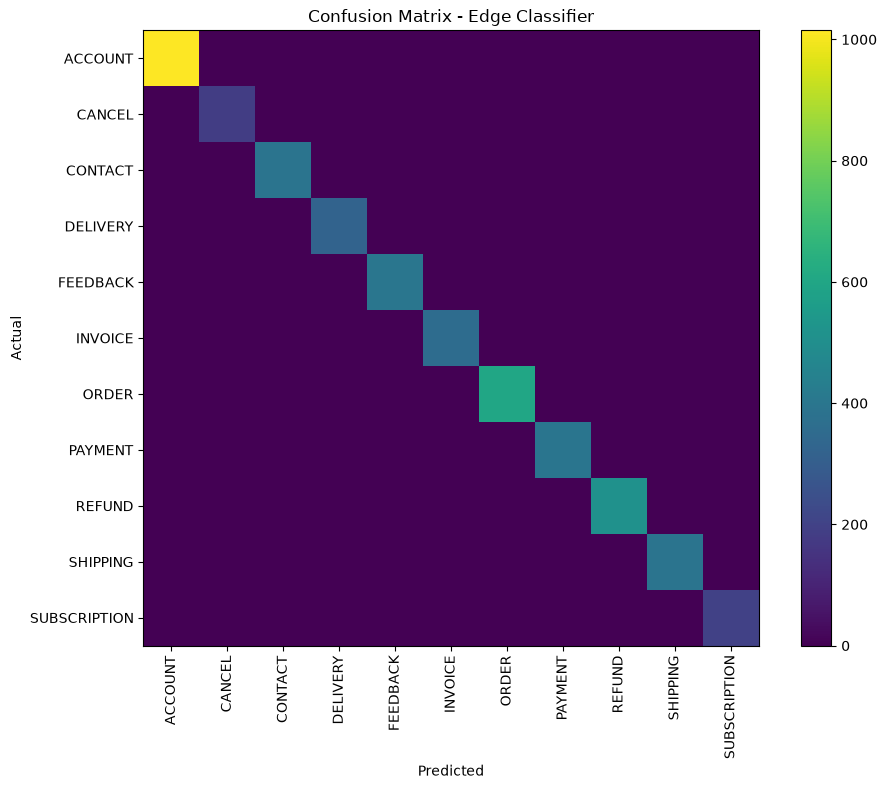

In [15]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - Edge Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

**Toelichting** De confusion matrix laat zien hoe goed het model presteert per categorie. Op de grafiek staan de echte labels op de y-as en de voorspelde labels op de x-as. Als het model het goed doet, zitten de hoge waarden op de diagonale lijn. Dat is hier het geval: bijna alle vakjes buiten de diagonaal zijn leeg of heel laag. Het model maakt dus maar weinig fouten.

### 4.5 Intentmodel

#### 4.5.1 Training Intent Classifier

In [16]:
X_intent = bitext_clean["text_clean"]
y_intent = bitext_clean["intent"]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_intent,
    y_intent,
    test_size=0.2,
    random_state=config.random_state,
    stratify=y_intent
)

intent_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=config.random_state
            )
        )
    ]
)

intent_model.fit(X_train_i, y_train_i)

intent_pred = intent_model.predict(X_test_i)
intent_accuracy = accuracy_score(y_test_i, intent_pred)
intent_macro_f1 = f1_score(y_test_i, intent_pred, average="macro")

print("Intent Accuracy:", round(intent_accuracy, 4))
print("Intent Macro F1:", round(intent_macro_f1, 4))
print(classification_report(y_test_i, intent_pred))

# Log resultaten in de ExperimentTracker
tracker.log_run(
    run_name="edge_intent_model_v1",
    params={
        "tfidf__max_features": 20000,
        "tfidf__ngram_range": "(1, 2)",
        "classifier__C": 1.0,
    },
    metrics={
        "accuracy": round(intent_accuracy, 4),
        "macro_f1": round(intent_macro_f1, 4),
    },
)

# Toon overzicht van alle gelogde experimenten
tracker.summary()


Intent Accuracy: 0.9918
Intent Macro F1: 0.9911
                          precision    recall  f1-score   support

            cancel_order       0.96      0.95      0.96        84
            change_order       0.95      0.99      0.97       169
 change_shipping_address       0.99      0.99      0.99       192
  check_cancellation_fee       1.00      1.00      1.00       186
           check_invoice       0.96      1.00      0.98       182
   check_payment_methods       0.99      0.99      0.99       198
     check_refund_policy       1.00      1.00      1.00       194
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.96      0.98       195
     contact_human_agent       0.96      0.99      0.98       194
          create_account       1.00      0.99      1.00       161
          delete_account       0.99      1.00      1.00       171
        delivery_options       0.99      1.00      1.00       126
         delivery_period   

**Toelichting** Het intentmodel wordt getraind om te begrijpen wat de bedoeling van een klantbericht is, bijvoorbeeld of iemand een bestelling wil annuleren of een accountprobleem heeft. De opzet is hetzelfde als bij het categoriemodel: een pipeline met TF-IDF en Logistic Regression. Het model haalt een accuracy van 99,18% en een macro F1-score van 99,11%, wat betekent dat het intenties van klanten goed herkent. Ook het classification report laat zien dat de meeste intenties een hoge score hebben. Hierdoor kan het systeem later automatisch herkennen wat een klant nodig heeft.


## 5 Simulatie Productomgeving

### 5.1 Twitter Data als Inkomende Tickets

De Twitter dataset bevat geen labels en wordt daarom gebruikt als simulatie van inkomende supporttickets. Alleen inkomende berichten worden meegenomen, dat zijn de echte klantvragen. Na het opschonen en verwijderen van dubbele of te korte berichten blijven er 26.299 bruikbare berichten over.


In [17]:
twitter_clean = twitter_df.copy()

twitter_clean = twitter_clean[twitter_clean["inbound"] == True]
twitter_clean["text_clean"] = twitter_clean["text"].apply(clean_text)

twitter_clean = twitter_clean[
    twitter_clean["text_clean"].str.len() > 5
].drop_duplicates(subset=["text_clean"])

print(twitter_clean.shape)
display(twitter_clean.head())

(26299, 8)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,text_clean
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0,USER and how do you propose we do that
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0,USER i have sent several private messages and ...
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0,USER i did
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN,USER is the worst customer service
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0,USER you gonna magically change your connectiv...


**Toelichting** Hier wordt de Twitter data klaargemaakt voor gebruik als nep productietickets. De dataset heeft geen labels, dus we gebruiken hem alleen om te testen of de modellen ook werken op echte, onbewerkte berichten. Na het filteren en opschonen blijven 26.299 berichten over die we kunnen gebruiken.

### 5.2 Classificatie toepassen op Twitter tickets

In [18]:
twitter_clean["predicted_category"] = edge_model.predict(
    twitter_clean["text_clean"]
)

twitter_clean["predicted_intent"] = intent_model.predict(
    twitter_clean["text_clean"]
)

display(
    twitter_clean[
        ["tweet_id", "author_id", "text", "predicted_category", "predicted_intent"]
    ].head(10)
)

,tweet_id,author_id,text,predicted_category,predicted_intent
1,2,115712,@sprintcare and how do you propose we do that,ACCOUNT,edit_account
2,3,115712,@sprintcare I have sent several private messag...,ACCOUNT,place_order
4,5,115712,@sprintcare I did.,ACCOUNT,edit_account
6,8,115712,@sprintcare is the worst customer service,CONTACT,contact_customer_service
8,12,115713,@sprintcare You gonna magically change your co...,ACCOUNT,edit_account
10,16,115713,@sprintcare Since I signed up with you....Sinc...,ACCOUNT,registration_problems
12,18,115713,@115714 y’all lie about your “great” connectio...,ACCOUNT,review
14,20,115715,"@115714 whenever I contact customer support, t...",ACCOUNT,contact_customer_service
16,22,115716,@Ask_Spectrum Would you like me to email you a...,ACCOUNT,edit_account
18,26,115716,@Ask_Spectrum I received this from your corpor...,SUBSCRIPTION,newsletter_subscription


**Toelichting** De getrainde modellen worden hier toegepast op de Twitterberichten. Het categoriemodel voorspelt het onderwerp van het ticket, zoals account of contact. Het intentmodel voorspelt wat de klant wil, zoals edit_account. Elk bericht krijgt automatisch een categorie en een intentie toegewezen.


### 5.3 Prioriteit bepalen met simpele business rules

In [ ]:
def assign_priority(text):
    # bepaal prioriteit op basis van trefwoorden in de tekst
    text = text.lower()

    high_keywords = ["urgent", "asap", "down", "error", "crash",
                     "not working", "broken", "refund", "charged"]
    medium_keywords = ["problem", "issue", "can't", "cannot",
                       "help", "failed", "missing"]

    if any(word in text for word in high_keywords):
        return "high"
    if any(word in text for word in medium_keywords):
        return "medium"
    return "low"


twitter_clean["priority"] = twitter_clean["text"].apply(assign_priority)

display(
    twitter_clean[
        ["text", "predicted_category", "predicted_intent", "priority"]
    ].head(10)
)


,text,predicted_category,predicted_intent,priority
1,@sprintcare and how do you propose we do that,ACCOUNT,edit_account,low
2,@sprintcare I have sent several private messag...,ACCOUNT,place_order,low
4,@sprintcare I did.,ACCOUNT,edit_account,low
6,@sprintcare is the worst customer service,CONTACT,contact_customer_service,low
8,@sprintcare You gonna magically change your co...,ACCOUNT,edit_account,low
10,@sprintcare Since I signed up with you....Sinc...,ACCOUNT,registration_problems,low
12,@115714 y’all lie about your “great” connectio...,ACCOUNT,review,low
14,"@115714 whenever I contact customer support, t...",ACCOUNT,contact_customer_service,low
16,@Ask_Spectrum Would you like me to email you a...,ACCOUNT,edit_account,low
18,@Ask_Spectrum I received this from your corpor...,SUBSCRIPTION,newsletter_subscription,low


**Toelichting** Tickets krijgen hier automatisch een prioriteit. Als een bericht woorden bevat zoals urgent of broken wordt dat als hoog geprioriteerd. Woorden als help of issue geven een medium prioriteit en de rest krijgt laag. Dit helpt supportmedewerkers om snel de dringende gevallen te herkennen.


### 5.4 Routering naar Support Squad


In [ ]:
def route_ticket(category):
    # stuur ticket naar de juiste supportafdeling op basis van categorie
    routing = {
        "ORDER": "Order Support Squad",
        "ACCOUNT": "Account Support Squad",
        "PAYMENT": "Billing Squad",
        "REFUND": "Billing Squad",
        "CONTACT": "General Support Squad",
        "FEEDBACK": "Customer Success Squad",
        "DELIVERY": "Logistics Squad"
    }
    return routing.get(category.upper(), "General Support Squad")


twitter_clean["assigned_squad"] = twitter_clean["predicted_category"].apply(route_ticket)

display(
    twitter_clean[
        ["text", "predicted_category", "priority", "assigned_squad"]
    ].head(10)
)


,text,predicted_category,priority,assigned_squad
1,@sprintcare and how do you propose we do that,ACCOUNT,low,Account Support Squad
2,@sprintcare I have sent several private messag...,ACCOUNT,low,Account Support Squad
4,@sprintcare I did.,ACCOUNT,low,Account Support Squad
6,@sprintcare is the worst customer service,CONTACT,low,General Support Squad
8,@sprintcare You gonna magically change your co...,ACCOUNT,low,Account Support Squad
10,@sprintcare Since I signed up with you....Sinc...,ACCOUNT,low,Account Support Squad
12,@115714 y’all lie about your “great” connectio...,ACCOUNT,low,Account Support Squad
14,"@115714 whenever I contact customer support, t...",ACCOUNT,low,Account Support Squad
16,@Ask_Spectrum Would you like me to email you a...,ACCOUNT,low,Account Support Squad
18,@Ask_Spectrum I received this from your corpor...,SUBSCRIPTION,low,General Support Squad


**Toelichting** Op basis van de voorspelde categorie wordt elk ticket doorgestuurd naar de juiste afdeling. ACCOUNT vragen gaan naar de Account Support Squad en DELIVERY vragen naar de Logistics Squad. In de tabel is te zien dat elk bericht automatisch een squad en prioriteit krijgt. Dit laat zien hoe alle onderdelen samenwerken: het bericht komt binnen, wordt geanalyseerd, krijgt een prioriteit en wordt daarna naar de goede afdeling gestuurd.

## 6 Cloud Model: Conceptantwoord Genereren

Het cloud model gebruikt Flan T5 om conceptantwoorden te genereren op basis van historische supportdata uit de Bitext dataset. Eerst wordt de voorspelde intent gebruikt om relevante voorbeeldantwoorden op te halen. Die worden vervolgens als context meegegeven aan het model, zodat het een passend antwoord kan formuleren. Dit lijkt op een RAG aanpak, maar dan in een vereenvoudigde vorm.


In [21]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

tokenizer = AutoTokenizer.from_pretrained(
    "google/flan-t5-small"
)

cloud_model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-small"
)

print("Cloud model loaded")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Cloud model loaded


In [ ]:
def generate_cloud_response(ticket_text, predicted_intent, knowledge_df):
    # zoek voorbeeldantwoorden op basis van intent en genereer een conceptreactie
    context_rows = knowledge_df[knowledge_df["intent"] == predicted_intent].head(3)

    if len(context_rows) == 0:
        return (
            "Thank you for contacting support. "
            "A support agent will review your request and get back to you shortly."
        )

    best_example_response = str(context_rows["response"].iloc[0])

    prompt = (
        "Write a customer support reply.\n"
        f"Message: {ticket_text}\n"
        f"Intent: {predicted_intent}\n"
        f"Example reply: {best_example_response}\n"
        "Reply:"
    )

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)

    outputs = cloud_model.generate(
        **inputs,
        max_new_tokens=60,
        num_beams=5,
        no_repeat_ngram_size=3,
        repetition_penalty=2.5,
        early_stopping=True,
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # controleer of de output bruikbaar is, anders gebruik het voorbeeldantwoord
    bad_output = (
        len(response.split()) < 6
        or "customer message" in response.lower()
        or "message:" in response.lower()
        or "intent:" in response.lower()
        or response.lower() == ticket_text.lower()
        or response.lower() in ["be professional", "be polite", "reply", "support response"]
    )

    if bad_output:
        response = best_example_response

    response = response.replace("{{Order Number}}", "[Order Number]")
    return response


In [23]:
test_ticket = "I want to cancel my order because I ordered the wrong item."

test_response = generate_cloud_response(
    test_ticket,
    "cancel_order",
    bitext_clean
)

print("Customer message:")
print(test_ticket)

print("\nAI draft response:")
print(test_response)

Customer message:
I want to cancel my order because I ordered the wrong item.

AI draft response:
I've understood you have a question regarding canceling order [Order Number], and I'm here to provide you with the information you need. Please go ahead and ask your question, and I'll do my best to assist you.


## 7 Monitoring

Monitoring is een belangrijk onderdeel van een MLOps systeem. In dit hoofdstuk wordt bijgehouden hoeveel tickets er binnenkomen per categorie, hoe de prioriteiten verdeeld zijn, hoe zeker het model is van zijn voorspellingen en of er datadrift is. Op basis van deze informatie kan worden besloten of het model opnieuw getraind moet worden.

### 7.1 Ticketvolume per Categorie


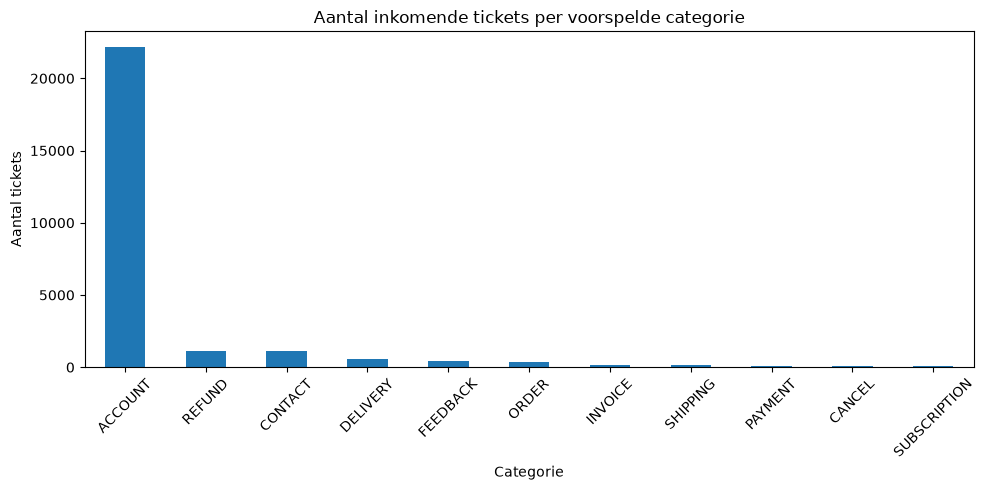

In [24]:
category_counts = twitter_clean["predicted_category"].value_counts()

plt.figure(figsize=(10, 5))
category_counts.plot(kind="bar")
plt.title("Aantal inkomende tickets per voorspelde categorie")
plt.xlabel("Categorie")
plt.ylabel("Aantal tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.2 Prioriteitsverdeling


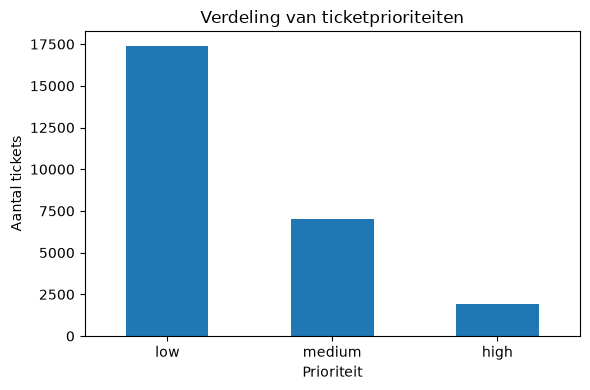

In [25]:
priority_counts = twitter_clean["priority"].value_counts()

plt.figure(figsize=(6, 4))
priority_counts.plot(kind="bar")
plt.title("Verdeling van ticketprioriteiten")
plt.xlabel("Prioriteit")
plt.ylabel("Aantal tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.3 Confidence Scores


,text,predicted_category,category_confidence
34680,"Fuck you and your ""oops life happens"" reminder...",CONTACT,0.136913
10810,Wells Fargo did me so fucking dirty omg https:...,CONTACT,0.139803
9215,"I will always stand by Taco Bell, but they did...",ACCOUNT,0.142747
3540,I! Fucking! Hate! Wells! Fargo!,ACCOUNT,0.144519
48958,Sprint fucking sucks ass😡,ACCOUNT,0.144519
31783,ALGUEM JA ATUALIZOU O IOS 11.1 ??? ME FALA SE ...,ACCOUNT,0.158456
43742,Happy Halloween!! What are you gonna be today?...,DELIVERY,0.159474
46148,Anyone have a #Dell XPS 15? Do you like it? #p...,ACCOUNT,0.161519
49386,"Really, @uber_support your going to charge me...",REFUND,0.163054
12906,@115955 are there any better DVRs? I just got ...,DELIVERY,0.164988


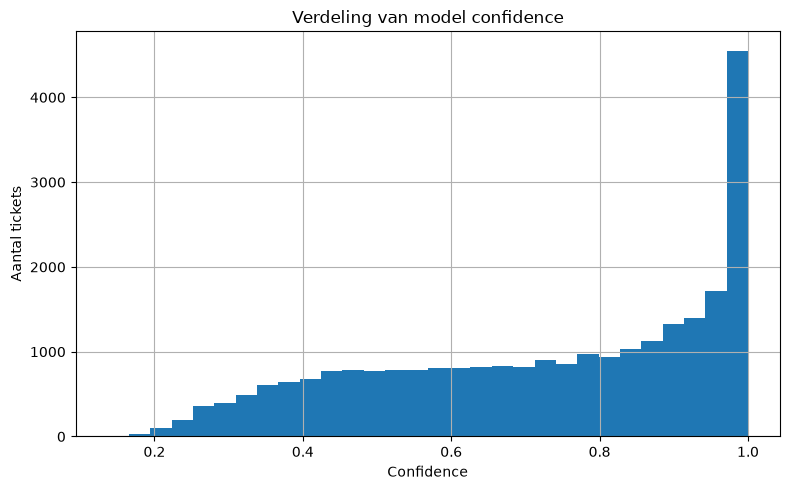

In [26]:
category_probabilities = edge_model.predict_proba(twitter_clean["text_clean"])
twitter_clean["category_confidence"] = category_probabilities.max(axis=1)

display(
    twitter_clean[
        ["text", "predicted_category", "category_confidence"]
    ].sort_values("category_confidence").head(10)
)

plt.figure(figsize=(8, 5))
twitter_clean["category_confidence"].hist(bins=30)
plt.title("Verdeling van model confidence")
plt.xlabel("Confidence")
plt.ylabel("Aantal tickets")
plt.tight_layout()
plt.show()

### 7.4 Datadrift Detectie

Datadrift treedt op als de eigenschappen van nieuwe data afwijken van de trainingsdata. Dat kan de kwaliteit van de voorspellingen verlagen. Hier gebruiken we de gemiddelde tekstlengte als simpele indicator. Als die te veel afwijkt van de trainingsdata, is er mogelijk sprake van drift en moet het model opnieuw getraind worden.


In [27]:
train_text_lengths = bitext_clean["text_clean"].str.len()
production_text_lengths = twitter_clean["text_clean"].str.len()

print("Gemiddelde lengte training:", train_text_lengths.mean())
print("Gemiddelde lengte productie:", production_text_lengths.mean())

drift_ratio = production_text_lengths.mean() / train_text_lengths.mean()

print("Drift ratio:", round(drift_ratio, 3))

if drift_ratio < 0.7 or drift_ratio > 1.3:
    print("Waarschuwing: mogelijke datadrift gedetecteerd.")
else:
    print("Geen sterke datadrift gedetecteerd.")

Gemiddelde lengte training: 45.77814152606396
Gemiddelde lengte productie: 92.59682877675958
Drift ratio: 2.023
Waarschuwing: mogelijke datadrift gedetecteerd.


### 7.5 Hertraining (Continuous Training)

Als er datadrift of prestatieverlies wordt gedetecteerd, kan het model automatisch opnieuw getraind worden. De functie retrain_model bevat de hele hertrainingsflow: de data wordt opgesplitst, GridSearchCV zoekt de beste parameters en de resultaten worden opgeslagen via de ExperimentTracker.


In [ ]:
def retrain_model(df, text_col, label_col, run_name, experiment_tracker, random_state=42):
    # hertraineer het model en log de resultaten in de tracker
    X = df[text_col]
    y = df[label_col]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    param_grid = {
        "tfidf__max_features": [10000, 15000],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "classifier__C": [0.1, 1.0, 10.0],
    }

    pipeline = Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(min_df=2)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=random_state,
                ),
            ),
        ]
    )

    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_tr, y_tr)

    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_te)

    acc = round(accuracy_score(y_te, y_pred), 4)
    mf1 = round(f1_score(y_te, y_pred, average="macro"), 4)

    experiment_tracker.log_run(
        run_name=run_name,
        params=gs.best_params_,
        metrics={"accuracy": acc, "macro_f1": mf1},
    )

    logging.info(f"Hertraining '{run_name}' voltooid: accuracy={acc}, macro_f1={mf1}")
    return best_model


DRIFT_THRESHOLD_LOW = 0.7
DRIFT_THRESHOLD_HIGH = 1.3

if drift_ratio < DRIFT_THRESHOLD_LOW or drift_ratio > DRIFT_THRESHOLD_HIGH:
    print("Drift gedetecteerd – hertraining gestart.")
    edge_model = retrain_model(
        df=bitext_clean,
        text_col="text_clean",
        label_col="category",
        run_name="edge_category_model_retrain",
        experiment_tracker=tracker,
        random_state=config.random_state,
    )
    joblib.dump(edge_model, config.output_dir / "edge_category_model.joblib")
    print("Hertraind model opgeslagen.")
else:
    print("Geen drift gedetecteerd – hertraining niet nodig.")


Drift gedetecteerd – hertraining gestart.
Run 'edge_category_model_retrain' gelogd: {'accuracy': 0.999, 'macro_f1': 0.9992}
Hertraind model opgeslagen.


## 8 Artefacten Opslaan

De getrainde modellen en de voorspellingen worden opgeslagen als bestanden. Dit is nodig zodat het systeem later opnieuw gebruikt kan worden zonder dat alles opnieuw getraind hoeft te worden.


In [29]:
joblib.dump(edge_model, config.output_dir / "edge_category_model.joblib")
joblib.dump(intent_model, config.output_dir / "edge_intent_model.joblib")

twitter_clean.to_csv(
    config.output_dir / "classified_twitter_tickets.csv",
    index=False
)

print("Modellen en output opgeslagen in:", config.output_dir)

Modellen en output opgeslagen in: flowsure_artifacts


## 9 Deployment

### 9.1 FastAPI Endpoint


In [30]:
fastapi_example = """
import re
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI()

category_model = joblib.load("flowsure_artifacts/edge_category_model.joblib")
intent_model = joblib.load("flowsure_artifacts/edge_intent_model.joblib")


def clean_text(text: str) -> str:
    \"\"\"Schoon tekst op voor ML-inferentie.\"\"\"
    text = str(text).lower()
    text = re.sub(r"http\\S+", " URL ", text)
    text = re.sub(r"@\\w+", " USER ", text)
    text = re.sub(r"{{.*?}}", " PLACEHOLDER ", text)
    text = re.sub(r"[^a-zA-Z0-9\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text


class TicketRequest(BaseModel):
    text: str


@app.post("/predict")
def predict_ticket(ticket: TicketRequest):
    cleaned = clean_text(ticket.text)
    category = category_model.predict([cleaned])[0]
    intent = intent_model.predict([cleaned])[0]
    category_confidence = float(category_model.predict_proba([cleaned]).max())

    return {
        "category": category,
        "intent": intent,
        "confidence": category_confidence,
    }
"""

print(fastapi_example)



import re
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app = FastAPI()

category_model = joblib.load("flowsure_artifacts/edge_category_model.joblib")
intent_model = joblib.load("flowsure_artifacts/edge_intent_model.joblib")


def clean_text(text: str) -> str:
    """Schoon tekst op voor ML-inferentie."""
    text = str(text).lower()
    text = re.sub(r"http\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"{{.*?}}", " PLACEHOLDER ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


class TicketRequest(BaseModel):
    text: str


@app.post("/predict")
def predict_ticket(ticket: TicketRequest):
    cleaned = clean_text(ticket.text)
    category = category_model.predict([cleaned])[0]
    intent = intent_model.predict([cleaned])[0]
    category_confidence = float(category_model.predict_proba([cleaned]).max())

    return {
        "category": category,
        "

### 9.2 Dockerfile


In [31]:
dockerfile_example = """
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY . .

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

print(dockerfile_example)


FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY . .

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



### 9.3 Requirements


In [32]:
requirements_example = """
fastapi
uvicorn
pandas
scikit-learn
joblib
numpy
"""

print(requirements_example)


fastapi
uvicorn
pandas
scikit-learn
joblib
numpy



### 9.4 CI/CD/CT Strategie

#### Continuous Integration (CI)
Bij elke codewijziging worden automatisch tests uitgevoerd. Dat zijn unit tests voor de functies zoals clean_text, validate_dataframe, assign_priority en route_ticket, een integratietest van de hele pipeline en een PEP8-check met flake8.

#### Continuous Deployment (CD)
Na een goedgekeurde merge naar de main branch wordt de applicatie automatisch uitgerold. Eerst wordt een Docker image gebouwd en naar een container registry gepusht. Daarna wordt de nieuwe versie op de productieserver gezet en wordt er een smoke test gedaan om te controleren of het predict-endpoint bereikbaar is.

#### Continuous Training (CT)
Elke week wordt automatisch gecontroleerd of het model nog goed genoeg werkt. Als de drift ratio buiten het interval van 0.7 tot 1.3 valt, als de gemiddelde confidence onder de 0.75 zakt of als de accuracy onder de 90% komt op nieuwe gelabelde feedback, wordt het model opnieuw getraind. Het nieuwe model wordt eerst gevalideerd op een aparte testset voordat het in productie wordt gezet. Het oude model blijft beschikbaar als back-up zodat een rollback mogelijk is.


## 10 Conclusie

In dit project hebben we een end to end MLOps pipeline gebouwd voor FlowSure. We hebben de Bitext dataset gebruikt om een lichtgewicht edge model te trainen dat tickets indeelt op categorie en intent. De Twitter dataset is gebruikt als simulatie van berichten die in een echte productieomgeving binnenkomen.

Het edge model is gebaseerd op TF IDF en Logistic Regression. Die keuze is bewust gemaakt omdat het model daardoor snel, klein en makkelijk te deployen is. Met GridSearchCV hebben we de beste hyperparameters gevonden en de resultaten zijn bijgehouden via de ExperimentTracker.

Voor het cloud model hebben we Flan T5 gebruikt om conceptantwoorden te genereren. We halen relevante voorbeeldantwoorden op uit de Bitext dataset op basis van de voorspelde intent en geven die als context mee aan het model. In een echte productieomgeving zou je hiervoor een groter taalmodel gebruiken.

Verder hebben we monitoring toegevoegd voor ticketvolume, prioriteiten, confidence en datadrift. Als de drift te groot wordt, kan het model automatisch opnieuw getraind worden via de retrain_model functie. De modellen worden opgeslagen als artefacten en kunnen via FastAPI en Docker worden gedeployed.


## 11 Bronnen

### Datasets
1. Bitext. (2023). *Bitext Gen AI Chatbot Customer Support Dataset* [Dataset]. Hugging Face. Verkregen van https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset
2. Kaggle / inbound. (2017). *Customer Support on Twitter* [Dataset]. Kaggle. Verkregen van https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter

### Machine Learning & MLOps
3. Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3e druk). O'Reilly Media.
4. Scikit-learn developers. (2024). *scikit-learn: Machine Learning in Python*. Verkregen van https://scikit-learn.org/stable/
5. Hugging Face. (2024). *Transformers: State-of-the-art Machine Learning for PyTorch, TensorFlow, and JAX*. Verkregen van https://huggingface.co/docs/transformers

### Deployment & CI/CD
6. FastAPI. (2024). *FastAPI framework*. Verkregen van https://fastapi.tiangolo.com/
7. Docker Inc. (2024). *Docker documentation*. Verkregen van https://docs.docker.com/
8. GitHub. (2024). *GitHub Actions documentation*. Verkregen van https://docs.github.com/en/actions

### Standaarden & Best Practices
9. Van der Aalst, W. et al. (2021). *Responsible data science*. Springer.
10. Huyen, C. (2022). *Designing machine learning systems*. O'Reilly Media.
